In [1]:
# Part 3'e geç. Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster. (Part 3, 4:19 - 40:40)

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('turkce_isimler.txt', 'r').read().splitlines()
words[:8]

['Ada',
 'Adaadem',
 'Adaahmet',
 'Adaali',
 'Adaalp',
 'Adaalparslan',
 'Adaalper',
 'Adaarda']

In [4]:
len(words)

103637

In [5]:
def lowercase(s):
    s = s.replace('İ', 'i').replace('I', 'ı')
    return s.lower()

words_cleaned = [lowercase(n) for n in words]
print(words_cleaned[:10])
words = words_cleaned.copy()

['ada', 'adaadem', 'adaahmet', 'adaali', 'adaalp', 'adaalparslan', 'adaalper', 'adaarda', 'adaasel', 'adaaslan']


In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'y', 23: 'z', 24: 'ç', 25: 'ö', 26: 'ü', 27: 'ğ', 28: 'ı', 29: 'ş', 0: '.'}
30


In [7]:
block_size = 3  # context length: how many characters do we take to predict the next one?

def building_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = building_dataset(words[:n1])     # 80%
Xdev, Ydev = building_dataset(words[n1:n2])   # 10%
Xte,  Yte  = building_dataset(words[n2:])     # 10%

torch.Size([891788, 3]) torch.Size([891788])
torch.Size([111351, 3]) torch.Size([111351])
torch.Size([111819, 3]) torch.Size([111819])


In [8]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(42) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12730


In [9]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 3.4020
  10000/ 200000: 1.5236
  20000/ 200000: 1.3397
  30000/ 200000: 1.5548
  40000/ 200000: 1.7864
  50000/ 200000: 1.7137
  60000/ 200000: 1.7819
  70000/ 200000: 1.6062
  80000/ 200000: 2.4242
  90000/ 200000: 1.5916
 100000/ 200000: 1.2791
 110000/ 200000: 1.4542
 120000/ 200000: 1.2471
 130000/ 200000: 1.4972
 140000/ 200000: 1.3869
 150000/ 200000: 1.5086
 160000/ 200000: 1.8928
 170000/ 200000: 1.0532
 180000/ 200000: 1.2556
 190000/ 200000: 1.3891


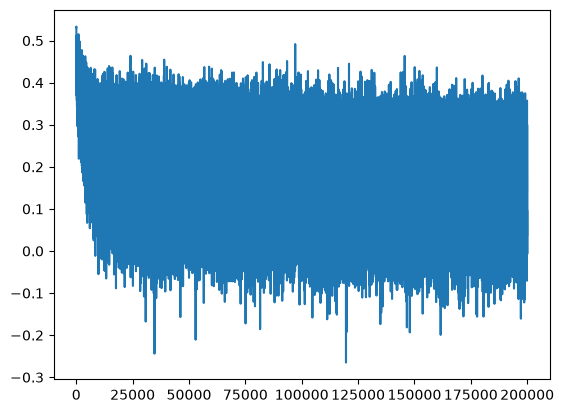

In [9]:
plt.plot(lossi)

In [10]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [11]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.4533244371414185
val 1.4667826890945435


## Görev 5

In [46]:
# eğer model tamamen rastgele tahmin yapsaydı, her karakter eşit olasılıkla gelirdi
# beklenen başlangıç loss'u:
-torch.tensor(1/30).log()

tensor(3.4012)

In [47]:
# parametreleri rastgele başlatıp  ilk adımdaki lossu öğrenelim
g = torch.Generator().manual_seed(42)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size*n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

26.633846282958984


In [48]:
#loss neden bu kadar yüksek logitlere bakalım logits = h @ W2 + b2
logits[0]

tensor([-17.0891,  -8.5803,  -2.8913,  27.1685,  14.6165,  -0.3338,   8.0681,
         -3.2140,   2.9476,  -5.7044,  -0.0473, -21.4818,  -0.6167,  34.2705,
        -10.2529,  16.1434,   2.2102, -32.0760,   4.5676,   5.4224,   2.0465,
        -13.6865, -10.4355,  13.3743,   5.0836,  -3.2936,   2.0214,  -9.4936,
          5.1643,  -3.2319], grad_fn=<SelectBackward0>)

In [49]:
# -21 +27 gibi çok büyük ve küçük değereler aldığını görüyoruz bu değerler lossu artırıyor.

In [50]:
# nasıl çözeriz? çıkış katmanını küçültmemiz gerek 
# Mantık: eğitimin başında model kararsız olmalı yani tüm karakterlere yakın olasılık vermeli logit'ler birbirine yakın olmalı 0 gibi

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size*n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

3.3955984115600586


In [51]:
# neden W2 ye 0.01 verdik ? 
# amaç: eğitim başlamadan önce model hiçbir karaktere aşırı güven duymasın yani tüm karakterler için ürettiği logitler birbirine yakın olsun 
# ideal olarak hepsi 0 civarı olmalı  böylece softmax sonrası olasılıklar neredeyse her karaktere eşit olasılıkta çıksın.
# logits = h @ W2 + b2 formülüne baktığımıda h değerleri zaten tanh çıktısı olduğu için -1 ile 1 aralığında sınırlıdır. Ama W2 çok büyük olursa h @ W2 olduğu için 
# toplam olduğu için rastgele büyük pozitif veya negatif değerlerin toplanması sonucu çok büyük sayılara ulaşabilir.
# W2'yi 0.01 ile çarpmak bu çarpımı küçük tutuyor logitler 0 a yakın kalıyor dolayısıyla softmax çıktısı yaklaşık değerler oluyor 
# loss da beklenen log(vocab_size) değerine yakın çıkıyor.

# W2 neden 0 değil öğrenme akışını tamamen durmasın diye çünkü 0 olsaydı giriş değerinin çıkış değerine bir etkisi olmayacaktı.
# neden b2 yi 0 yaptık ? 
# çünkü b2 * 0 her karaktere sistematik keyfi bir önyargı eklenmesini engelliyor. b2 zaten h dan  gelen bilgiyi taşımıyor sadece sabit bir kaydırma olduğu için sıfır yapmak gradyan akışını engellemiyor.

Text(0, 0.5, 'örnek 500 rastgele satır')

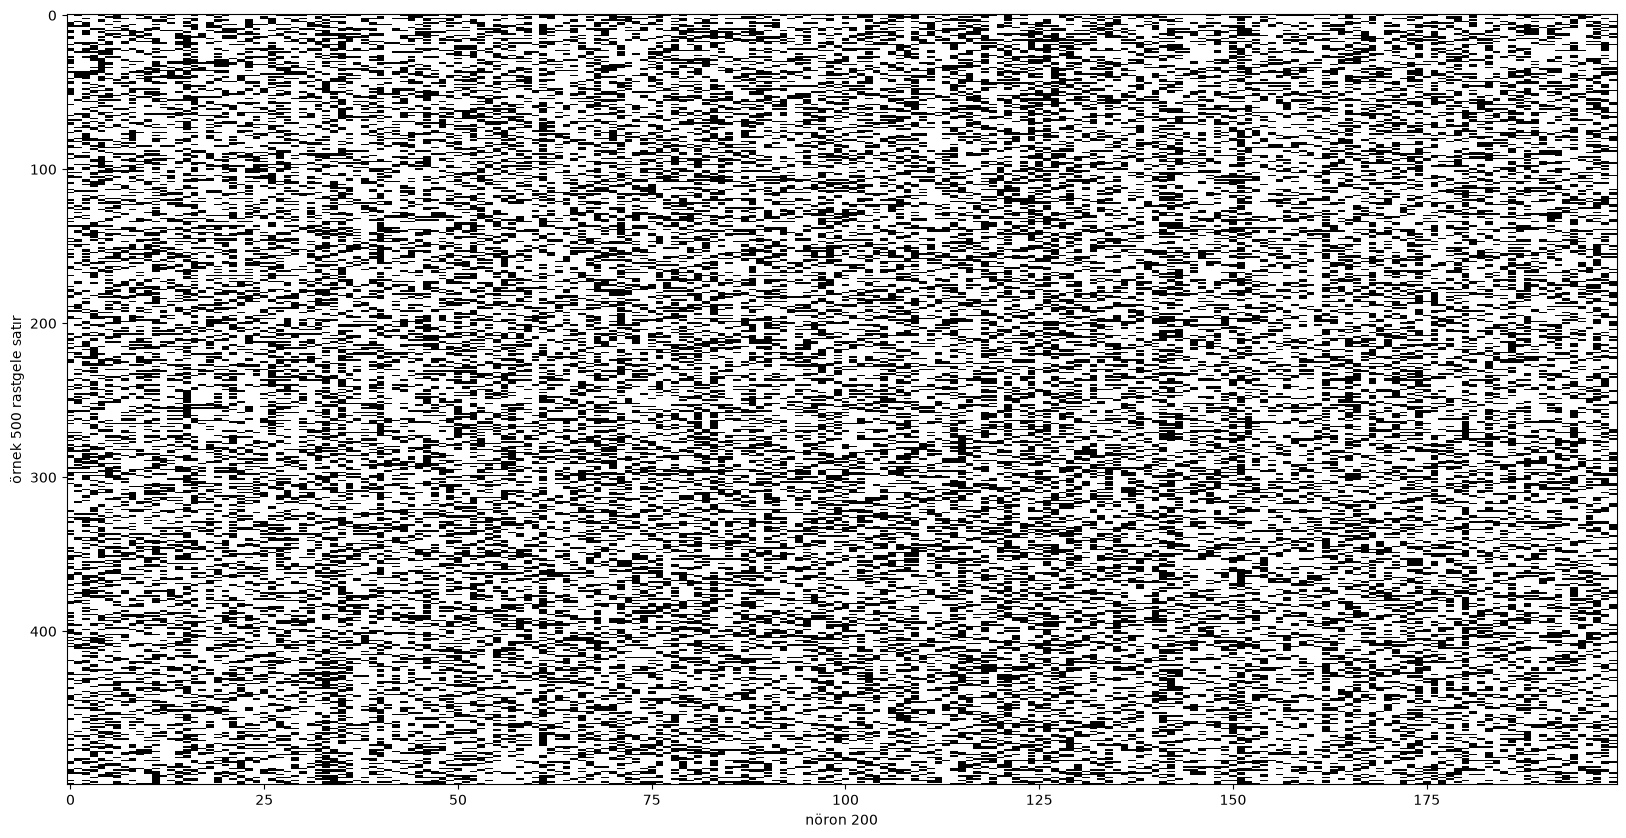

In [52]:
sample_idx = torch.randint(0, h.shape[0], (500,)) 
h_sample = h[sample_idx].abs().detach().numpy() > 0.99

plt.figure(figsize=(20,10))
plt.imshow(h_sample, cmap='gray', interpolation='nearest', aspect='auto')
plt.xlabel('nöron 200')
plt.ylabel('örnek 500 rastgele satır')

(array([64908595.,  4058449.,  2466321.,  1943751.,  1398883.,  1338667.,
         1021255.,   976444.,   772996.,   720598.,   721694.,   754681.,
          673161.,   581165.,   627104.,   534485.,   488367.,   505899.,
          562809.,   563419.,   642778.,   457890.,   469442.,   447628.,
          449825.,   477970.,   528293.,   703739.,   456086.,   519399.,
          485639.,   497750.,   490086.,   531113.,   607144.,   673706.,
          598580.,   788609.,   675751.,   794379.,   750416.,   816357.,
          870195.,  1052927.,  1091816.,  1549834.,  1971523.,  2316872.,
         4594365., 66428745.]),
 array([-1.        , -0.95999998, -0.92000002, -0.88      , -0.84000003,
        -0.80000001, -0.75999999, -0.72000003, -0.68000001, -0.63999999,
        -0.60000002, -0.56      , -0.51999998, -0.48000002, -0.44      ,
        -0.40000004, -0.36000001, -0.31999999, -0.28000003, -0.24000001,
        -0.20000005, -0.16000003, -0.12      , -0.08000004, -0.04000002,
         0.

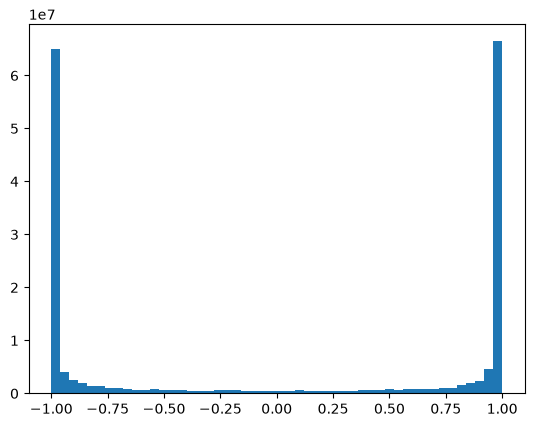

In [53]:
plt.hist(h.view(-1).detach().numpy(), 50)

In [17]:
# Bu, Kaiming initten önceki düzeltilmemiş modelin çıktısıdır. 
# tanh'a giren ham değerler çok geniş bir aralıkta dağıldığı için -15, +20 gibi tanh fonksiyonu bu kadar büyük girdilerde zaten neredeyse tamamen -1 veya +1'e yapışıyor yani matematiksel olarak tanh(15) ≈ 0.9999999..
# tanh'ın türevi: d(tanh(x))/dx = 1 - tanh(x)^2. Eğer tanh(x) ≈ ±1 ise bu türev ≈ 1 - 1 = 0a çok yakın oluyor. 
# Yani bu nöronlardan gradyan neredeyse hiç geçmiyor backward pass sırasında bu nöronlar öğrenmeyi durdurmuş gibi davranıyor. 
# Grafikte neredeyse tüm değerlerin ±1 de olması ağın büyük kısmının şu an öğrenemez durumda olduğu anlamına geliyor.

In [54]:
print('Doygun (|h|>0.99) oranı: %.2f%%' % (100 * (h.abs() > 0.99).float().mean().item()))

Doygun (|h|>0.99) oranı: 64.88%


In [57]:
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

emb = C[Xtr]
hpreact = emb.view(-1, block_size*n_embd) @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

print('Doygun (|h|>0.99) oranı: %.2f%%' % (100 * (h.abs() > 0.99).float().mean().item()))

3.4078686237335205
Doygun (|h|>0.99) oranı: 2.75%


Text(0, 0.5, 'örnek 500 rastgele satır')

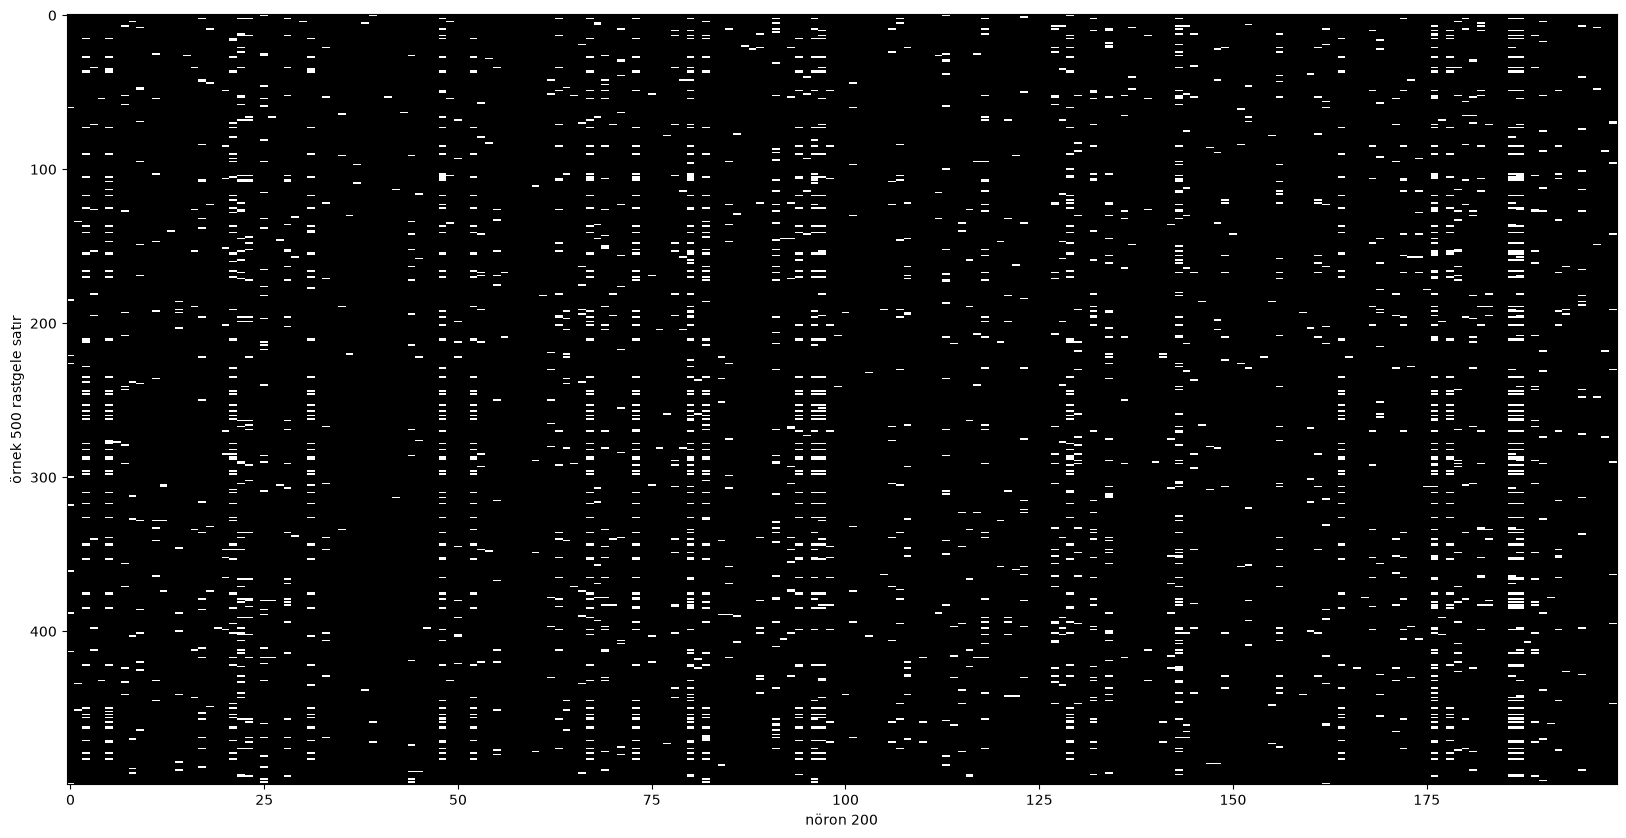

In [58]:
sample_idx = torch.randint(0, h.shape[0], (500,)) 
h_sample = h[sample_idx].abs().detach().numpy() > 0.99

plt.figure(figsize=(20,10))
plt.imshow(h_sample, cmap='gray', interpolation='nearest', aspect='auto')
plt.xlabel('nöron 200')
plt.ylabel('örnek 500 rastgele satır')

In [36]:
# "W2/b2 yi küçültmek başlangıç loss'unu düzeltti
#  W1/b1'i küçültmek ise tanh'ın doygunluğunu önleyip nöronların öğrenmeye devam edebilmesini sağladı

In [59]:
# kaiming init formülünü hesaplama   
fan_in = block_size * n_embd
gain = 5/3   # tanh için Kaimingin önerdiği sabit
std = gain / (fan_in**0.5)
print(std)

0.3042903097250923


In [60]:
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * (5/3) / ((block_size*n_embd)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

emb = C[Xtr]
hpreact = emb.view(-1, block_size*n_embd) @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

print('Doygun (|h|>0.99) oranı: %.2f%%' % (100 * (h.abs() > 0.99).float().mean().item()))

3.412374973297119
Doygun (|h|>0.99) oranı: 12.24%


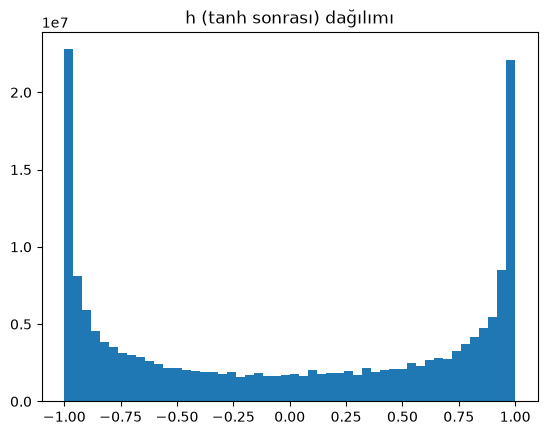

In [61]:
plt.hist(h.view(-1).detach().numpy(), 50)
plt.title('h (tanh sonrası) dağılımı')
plt.show()